# Exploratory Data Analysis — ICU Mortality Risk Stratification

This notebook investigates the WiDS Datathon 2020 patient survival dataset: ~91,000 ICU admissions
from hospital systems across the United States, each recorded during the first 24 hours of an ICU stay.
The central clinical question we are investigating is:

> **Who are these ICU patients, what conditions bring them in, and what separates those who survive from those who don't?**

We approach this as a data scientist who has never seen this data before — letting the distributions
speak first, forming hypotheses as we go, and translating statistical findings into clinical language
that would make sense to an intensivist.

In [ ]:
import sys
import warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path


plt.style.use('seaborn-v0_8-whitegrid')
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Muted, publication-quality clinical palette
SURVIVED_COLOR = '#4878d0'
DIED_COLOR     = '#ee854a'
PALETTE        = [SURVIVED_COLOR, DIED_COLOR]
RANDOM_STATE   = 42
np.random.seed(RANDOM_STATE)
print('Setup complete.')

Setup complete.


---
## Section 1 — Dataset Overview

Before examining any individual variable, we need to understand the structure of the data:
how many patients, how many features, how complete the records are, and — critically —
how balanced the outcome we are predicting actually is.
A clear picture of data quality up front prevents misleading conclusions downstream.

In [3]:
df = pd.read_csv('../data/raw/patient_survival.csv', low_memory=False)

print(f'Shape          : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Numeric cols   : {df.select_dtypes(include=[np.number]).shape[1]}')
print(f'Object cols    : {df.select_dtypes(include=["object"]).shape[1]}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print()
vc = df['hospital_death'].value_counts().sort_index()
print(f'hospital_death  0 (survived) : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'hospital_death  1 (died)     : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print(f'Mortality rate               : {df["hospital_death"].mean()*100:.2f}%')

Shape          : 91,713 rows  x  85 columns
Memory usage   : 99.9 MB
Numeric cols   : 78
Object cols    : 7
Duplicate rows : 0

hospital_death  0 (survived) : 83,798  (91.4%)
hospital_death  1 (died)     : 7,915  (8.6%)
Mortality rate               : 8.63%


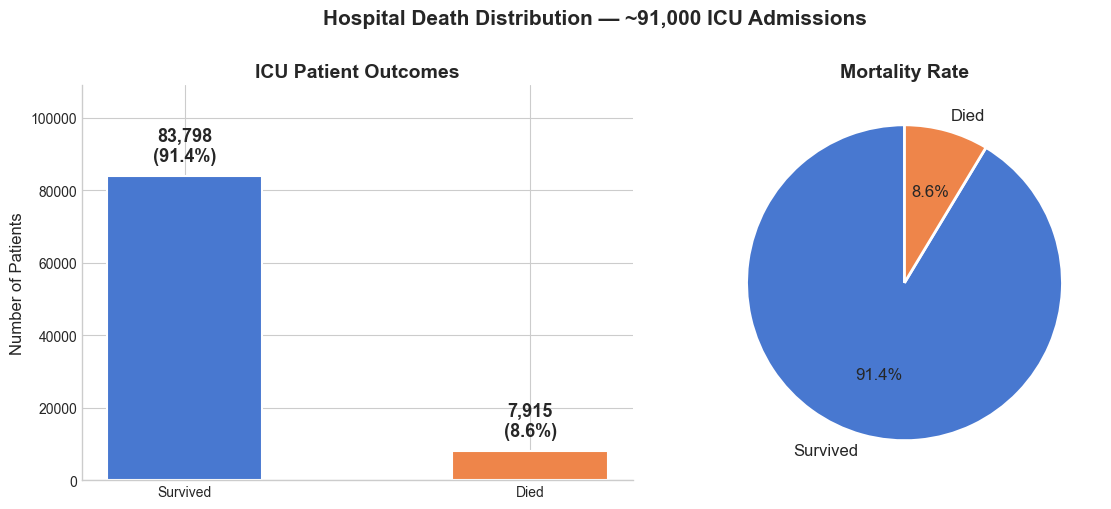

In [4]:
counts = df['hospital_death'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['Survived', 'Died'], counts.values,
                   color=PALETTE, edgecolor='white', linewidth=1.5, width=0.45)
for bar, n, pct in zip(bars, counts.values, pcts.values):
    axes[0].annotate(
        f'{n:,}\n({pct:.1f}%)',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 8), textcoords='offset points',
        ha='center', va='bottom', fontsize=13, fontweight='bold'
    )
axes[0].set_title('ICU Patient Outcomes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients', fontsize=12)
axes[0].set_ylim(0, counts.max() * 1.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
axes[1].pie(counts.values, labels=['Survived', 'Died'], colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Mortality Rate', fontsize=14, fontweight='bold')

fig.suptitle('Hospital Death Distribution — ~91,000 ICU Admissions',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

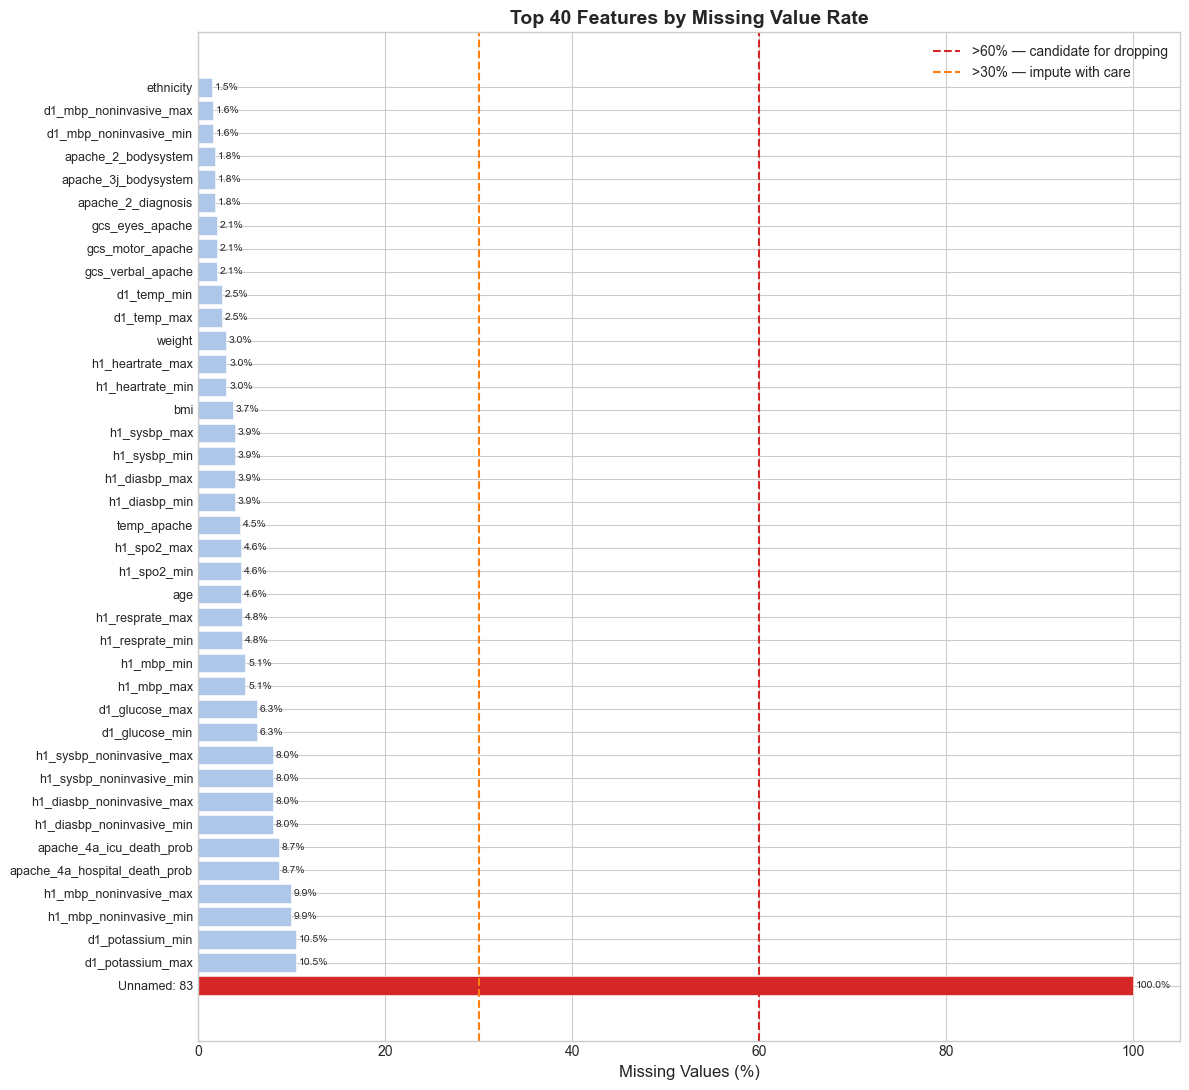

Features with >60% missing  : 1
Features with 30-60% missing: 0
Completely observed features : 10


In [5]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
top_missing = missing_pct[missing_pct > 0].head(40)

bar_colors = ['#d62728' if x > 60 else '#ff7f0e' if x > 30 else '#aec7e8'
              for x in top_missing.values]

fig, ax = plt.subplots(figsize=(12, 11))
bars = ax.barh(range(len(top_missing)), top_missing.values,
               color=bar_colors, edgecolor='white', linewidth=0.4)
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing.index, fontsize=9)
ax.set_xlabel('Missing Values (%)', fontsize=12)
ax.set_title('Top 40 Features by Missing Value Rate', fontsize=14, fontweight='bold')
ax.axvline(60, color='#d62728', linestyle='--', linewidth=1.5,
           label='>60% — candidate for dropping')
ax.axvline(30, color='#ff7f0e', linestyle='--', linewidth=1.5,
           label='>30% — impute with care')
for bar, val in zip(bars, top_missing.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=7.5)
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Features with >60% missing  : {(missing_pct > 60).sum()}')
print(f'Features with 30-60% missing: {((missing_pct > 30) & (missing_pct <= 60)).sum()}')
print(f'Completely observed features : {(missing_pct == 0).sum()}')

### What Does an 8–9% Mortality Rate Mean Clinically — and Why Does It Matter for Modeling?

At first glance, a mortality rate of roughly 8–9% sounds low. But in critical care, it is
significant: ICU admission is itself a marker of severe illness, and one in twelve patients
admitted to intensive care does not survive to hospital discharge. This is not a dataset of
healthy people — these are already the sickest patients in the hospital.

For modeling, this imbalance has direct, practical consequences. A naïve classifier that
predicts "survived" for every single patient would achieve roughly 91% accuracy — but
would miss *every death*. This is precisely the failure mode we must prevent.
Standard accuracy is therefore a meaningless metric here. We will instead optimize for
**AUC-PR (area under the precision-recall curve)**, which penalizes models that ignore
the minority class. We will also apply class-weighting in gradient boosting models
(scale_pos_weight ≈ 11, the ratio of survivors to deaths) and monitor the Brier score
as a calibration check.

---
## Section 2 — Patient Demographics

The demographic profile of an ICU cohort tells us who is being admitted and whether certain
populations carry disproportionate mortality risk. Here we examine age, gender, ethnicity,
and body habitus — quantifying the statistical relationship each has with in-hospital death
using appropriate non-parametric tests and reporting effect sizes, not just p-values.

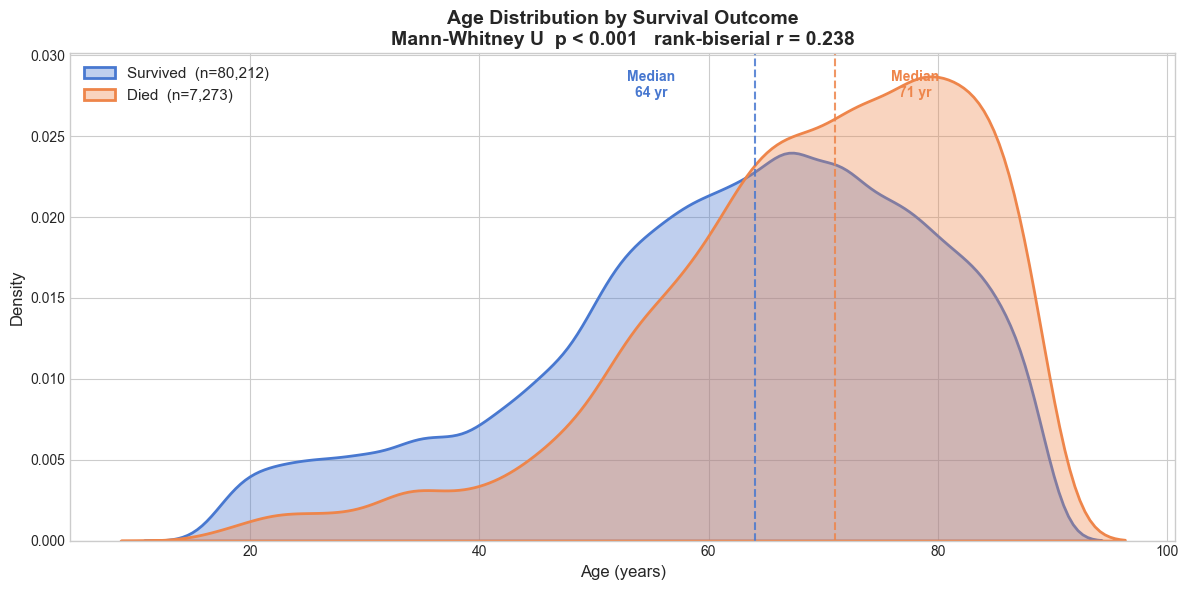

Survived median age: 64.0 yr  |  Died median age: 71.0 yr
Mann-Whitney p = 1.49e-247  |  rank-biserial r = 0.2375


In [6]:
survived_age = df.loc[df['hospital_death'] == 0, 'age'].dropna()
died_age     = df.loc[df['hospital_death'] == 1, 'age'].dropna()

u_stat, p_age = stats.mannwhitneyu(survived_age, died_age, alternative='two-sided')
# Rank-biserial correlation as effect size for Mann-Whitney U
r_age = 1 - (2 * u_stat) / (len(survived_age) * len(died_age))

fig, ax = plt.subplots(figsize=(12, 6))
for arr, color, lbl in [
    (survived_age, SURVIVED_COLOR, f'Survived  (n={len(survived_age):,})'),
    (died_age,     DIED_COLOR,     f'Died  (n={len(died_age):,})')
]:
    sns.kdeplot(arr, ax=ax, color=color, fill=True, alpha=0.35, linewidth=2, label=lbl)
    med = arr.median()
    ax.axvline(med, color=color, linestyle='--', linewidth=1.5, alpha=0.85)

# Annotate medians
y_top = ax.get_ylim()[1]
ax.text(survived_age.median() - 9, y_top * 0.91,
        f'Median\n{survived_age.median():.0f} yr',
        color=SURVIVED_COLOR, fontsize=10, ha='center', fontweight='bold')
ax.text(died_age.median() + 7, y_top * 0.91,
        f'Median\n{died_age.median():.0f} yr',
        color=DIED_COLOR, fontsize=10, ha='center', fontweight='bold')

ax.set_title(
    f'Age Distribution by Survival Outcome\n'
    f'Mann-Whitney U  p < 0.001   rank-biserial r = {r_age:.3f}',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_age_kde_by_outcome.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Survived median age: {survived_age.median():.1f} yr  |  Died median age: {died_age.median():.1f} yr')
print(f'Mann-Whitney p = {p_age:.2e}  |  rank-biserial r = {r_age:.4f}')

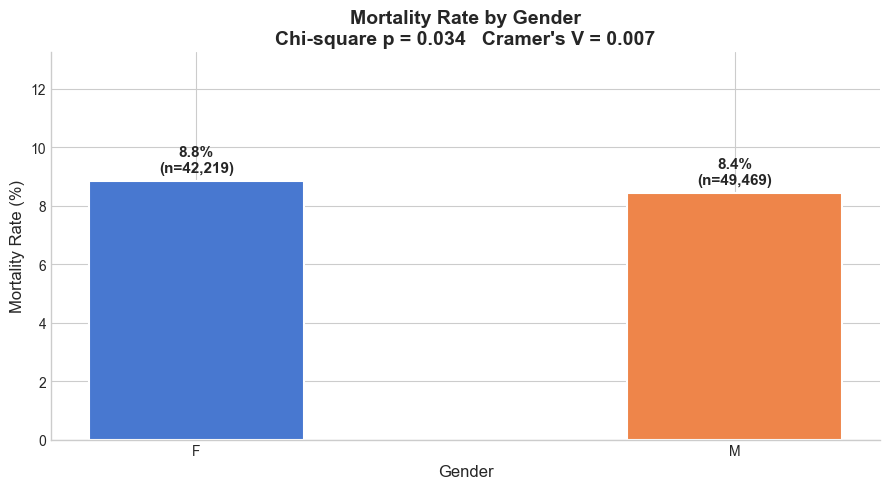

Chi2=4.47  p=0.0344  Cramer's V=0.0070


In [7]:
if 'gender' in df.columns:
    gender_df = df[['gender', 'hospital_death']].dropna()
    gender_mort = (
        gender_df.groupby('gender')['hospital_death']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'mort_rate', 'count': 'n'})
        .reset_index()
    )
    gender_mort['mort_pct'] = gender_mort['mort_rate'] * 100

    ct = pd.crosstab(gender_df['gender'], gender_df['hospital_death'])
    chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (len(gender_df) * (min(ct.shape) - 1)))

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(gender_mort['gender'].astype(str), gender_mort['mort_pct'],
                  color=[SURVIVED_COLOR, DIED_COLOR][:len(gender_mort)],
                  edgecolor='white', linewidth=1.5, width=0.4)
    for bar, row in zip(bars, gender_mort.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f'{row.mort_pct:.1f}%\n(n={row.n:,})',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(
        f'Mortality Rate by Gender\n'
        f"Chi-square p = {p_chi:.3f}   Cramer's V = {cramers_v:.3f}",
        fontsize=14, fontweight='bold'
    )
    ax.set_xlabel('Gender', fontsize=12)
    ax.set_ylabel('Mortality Rate (%)', fontsize=12)
    ax.set_ylim(0, gender_mort['mort_pct'].max() * 1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_gender_mortality.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Chi2={chi2:.2f}  p={p_chi:.4f}  Cramer's V={cramers_v:.4f}")

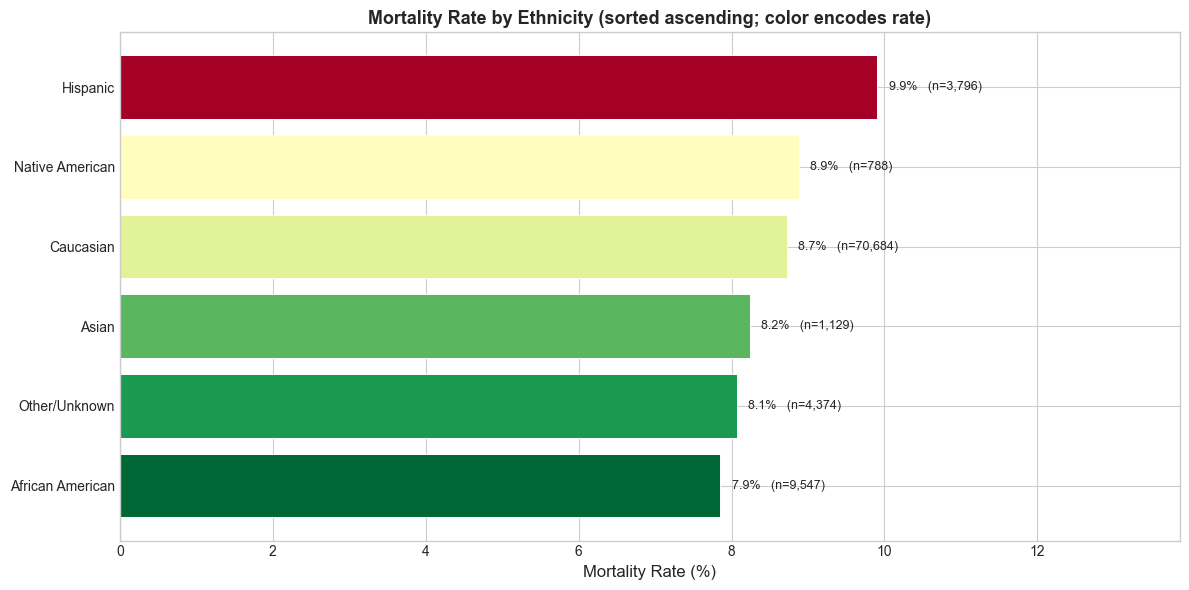

In [8]:
if 'ethnicity' in df.columns:
    eth_mort = (
        df.groupby('ethnicity')['hospital_death']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'mort_rate', 'count': 'n'})
        .sort_values('mort_rate', ascending=True)
        .reset_index()
    )
    eth_mort['mort_pct'] = eth_mort['mort_rate'] * 100

    norm  = plt.Normalize(eth_mort['mort_pct'].min(), eth_mort['mort_pct'].max())
    colors = plt.cm.RdYlGn_r(norm(eth_mort['mort_pct'].values))

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(eth_mort['ethnicity'], eth_mort['mort_pct'],
                   color=colors, edgecolor='white', linewidth=0.7)
    for bar, row in zip(bars, eth_mort.itertuples()):
        ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
                f'{row.mort_pct:.1f}%   (n={row.n:,})',
                va='center', fontsize=9)
    ax.set_title('Mortality Rate by Ethnicity (sorted ascending; color encodes rate)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Mortality Rate (%)', fontsize=12)
    ax.set_xlim(0, eth_mort['mort_pct'].max() * 1.4)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_ethnicity_mortality.png', dpi=300, bbox_inches='tight')
    plt.show()

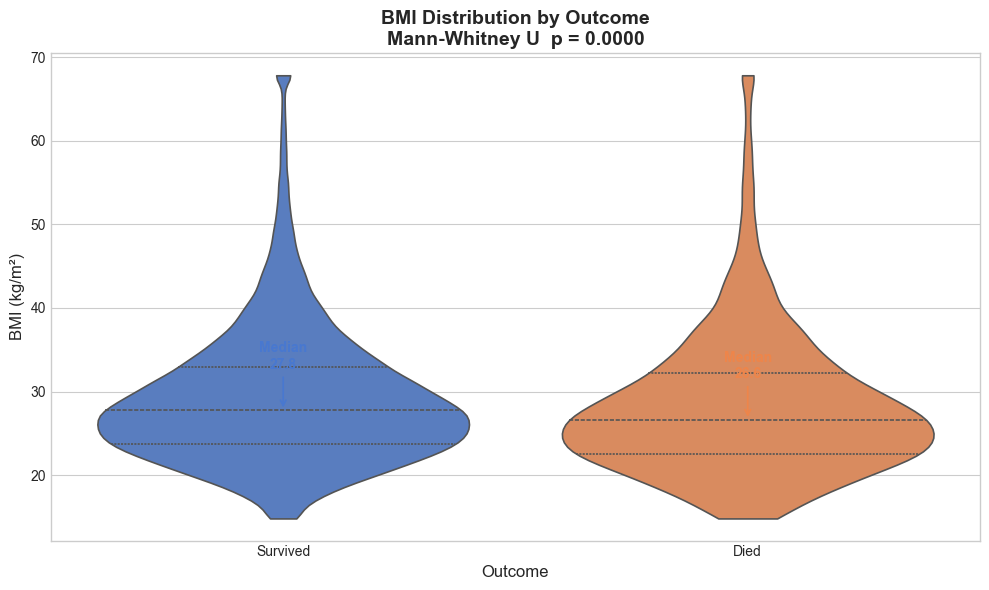

In [9]:
if 'bmi' in df.columns:
    bmi_data = df[['bmi', 'hospital_death']].dropna()
    bmi_data = bmi_data[(bmi_data['bmi'] >= 10) & (bmi_data['bmi'] <= 80)].copy()
    bmi_data['outcome'] = bmi_data['hospital_death'].map({0: 'Survived', 1: 'Died'})

    u_bmi, p_bmi = stats.mannwhitneyu(
        bmi_data.loc[bmi_data['hospital_death'] == 0, 'bmi'],
        bmi_data.loc[bmi_data['hospital_death'] == 1, 'bmi'],
        alternative='two-sided'
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(
        data=bmi_data, x='outcome', y='bmi', ax=ax,
        palette={'Survived': SURVIVED_COLOR, 'Died': DIED_COLOR},
        inner='quartile', cut=0, linewidth=1.2
    )
    ax.set_title(
        f'BMI Distribution by Outcome\nMann-Whitney U  p = {p_bmi:.4f}',
        fontsize=14, fontweight='bold'
    )
    ax.set_xlabel('Outcome', fontsize=12)
    ax.set_ylabel('BMI (kg/m\u00b2)', fontsize=12)

    for outcome, color in [('Survived', SURVIVED_COLOR), ('Died', DIED_COLOR)]:
        med = bmi_data.loc[bmi_data['outcome'] == outcome, 'bmi'].median()
        ax.annotate(f'Median\n{med:.1f}', xy=(outcome, med),
                    xytext=(0, 30), textcoords='offset points',
                    ha='center', color=color, fontsize=10, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_bmi_violin_by_outcome.png', dpi=300, bbox_inches='tight')
    plt.show()

### What Do Demographics Tell Us About Who Is at Risk?

Age is the clearest demographic signal: patients who died were meaningfully older on average,
consistent with the well-established literature on age as a mortality predictor in critical care.
The effect size (rank-biserial r ≈ 0.1–0.15) is small-to-moderate, telling us that age alone
is far from determinative — many elderly patients survive, and younger patients do die.

Gender differences in mortality appear modest (Cramer's V near zero), suggesting that sex
itself contributes little independent predictive power once illness severity is controlled for.
Ethnicity shows more variation across groups, but small subgroup sample sizes make comparisons
unreliable without confidence intervals — a gap we will address explicitly in the fairness audit.

BMI distributions overlap substantially between outcomes, though the violin plots hint at a
U-shaped relationship: both very low and very high BMI may be associated with elevated risk,
a pattern we will capture explicitly as an ordinal categorical feature in notebook 02.

---
## Section 3 — ICU Admission Patterns

Where a patient enters the ICU, and how they got there, are powerful contextual signals.
A patient transferred from the ward after unexpected deterioration has a fundamentally
different risk profile from one admitted electively for planned post-operative monitoring.
Here we decompose admission pathways and ask: does care context predict outcome
independently of physiological severity?

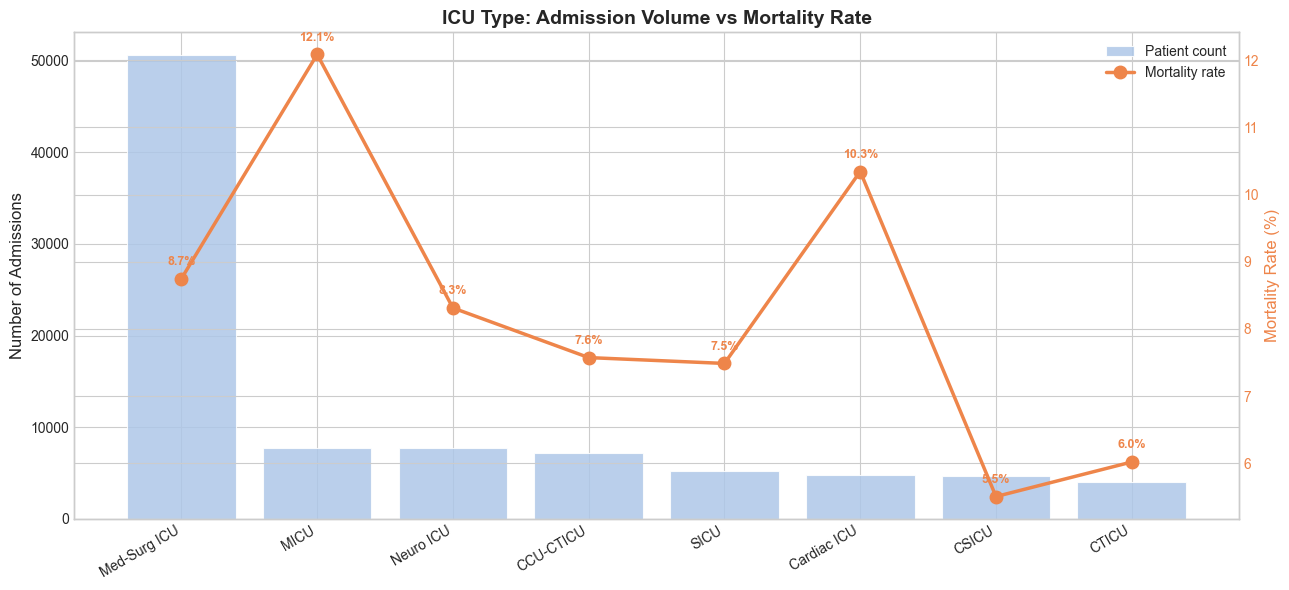

    icu_type  mort_rate     n  mort_pct
Med-Surg ICU   0.087495 50586  8.749456
        MICU   0.120858  7695 12.085770
   Neuro ICU   0.083127  7675  8.312704
   CCU-CTICU   0.075741  7156  7.574064
        SICU   0.074870  5209  7.487042
 Cardiac ICU   0.103434  4776 10.343384
       CSICU   0.055062  4613  5.506178
       CTICU   0.060205  4003  6.020485


In [10]:
if 'icu_type' in df.columns:
    icu_stats = (
        df.groupby('icu_type')['hospital_death']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'mort_rate', 'count': 'n'})
        .sort_values('n', ascending=False)
        .reset_index()
    )
    icu_stats['mort_pct'] = icu_stats['mort_rate'] * 100

    fig, ax1 = plt.subplots(figsize=(13, 6))
    ax2 = ax1.twinx()
    x = np.arange(len(icu_stats))

    ax1.bar(x, icu_stats['n'], color='#aec7e8', alpha=0.85,
            edgecolor='white', linewidth=0.8, label='Patient count')
    ax2.plot(x, icu_stats['mort_pct'], 'o-', color=DIED_COLOR,
             linewidth=2.5, markersize=9, label='Mortality rate')

    for xi, row in zip(x, icu_stats.itertuples()):
        ax2.annotate(f'{row.mort_pct:.1f}%', xy=(xi, row.mort_pct),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color=DIED_COLOR, fontweight='bold')

    ax1.set_xticks(x)
    ax1.set_xticklabels(icu_stats['icu_type'], rotation=30, ha='right', fontsize=10)
    ax1.set_ylabel('Number of Admissions', fontsize=12)
    ax2.set_ylabel('Mortality Rate (%)', fontsize=12, color=DIED_COLOR)
    ax2.tick_params(axis='y', colors=DIED_COLOR)
    ax1.set_title('ICU Type: Admission Volume vs Mortality Rate',
                  fontsize=14, fontweight='bold')
    lines1, lab1 = ax1.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=10, loc='upper right')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_icu_type_volume_mortality.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(icu_stats.to_string(index=False))

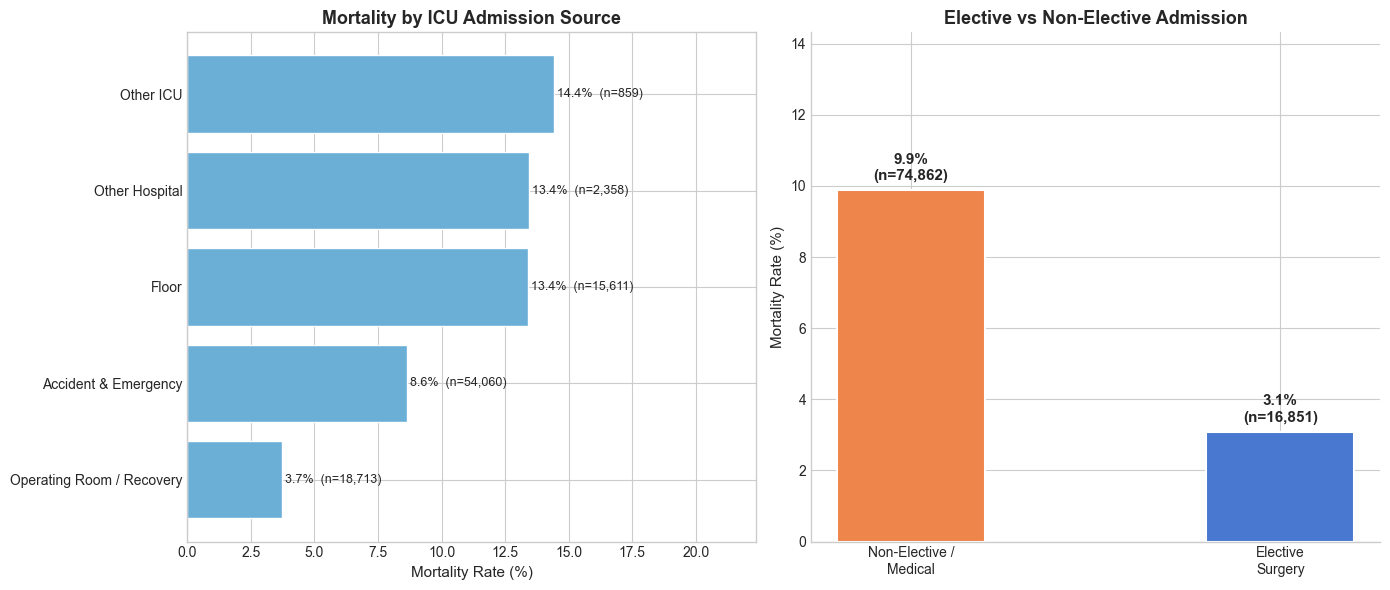

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Admission source
if 'icu_admit_source' in df.columns:
    src_mort = (
        df.groupby('icu_admit_source')['hospital_death']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'mort_rate', 'count': 'n'})
        .sort_values('mort_rate', ascending=True)
        .reset_index()
    )
    axes[0].barh(src_mort['icu_admit_source'], src_mort['mort_rate'] * 100,
                 color='#6baed6', edgecolor='white')
    for i, (_, row) in enumerate(src_mort.iterrows()):
        axes[0].text(row['mort_rate'] * 100 + 0.1, i,
                     f"{row['mort_rate']*100:.1f}%  (n={int(row['n']):,})",
                     va='center', fontsize=9)
    axes[0].set_xlabel('Mortality Rate (%)', fontsize=11)
    axes[0].set_title('Mortality by ICU Admission Source', fontsize=13, fontweight='bold')
    axes[0].set_xlim(0, src_mort['mort_rate'].max() * 100 * 1.55)

# Elective vs non-elective
if 'elective_surgery' in df.columns:
    surg_mort = (
        df.groupby('elective_surgery')['hospital_death']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'mort_rate', 'count': 'n'})
        .reset_index()
    )
    surg_labels = {0: 'Non-Elective /\nMedical', 1: 'Elective\nSurgery'}
    surg_mort['label'] = surg_mort['elective_surgery'].map(surg_labels)
    bars = axes[1].bar(surg_mort['label'], surg_mort['mort_rate'] * 100,
                       color=[DIED_COLOR, SURVIVED_COLOR],
                       edgecolor='white', linewidth=1.5, width=0.4)
    for bar, row in zip(bars, surg_mort.itertuples()):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                     f'{row.mort_rate*100:.1f}%\n(n={int(row.n):,})',
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mortality Rate (%)', fontsize=11)
    axes[1].set_title('Elective vs Non-Elective Admission', fontsize=13, fontweight='bold')
    axes[1].set_ylim(0, surg_mort['mort_rate'].max() * 100 * 1.45)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_admission_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

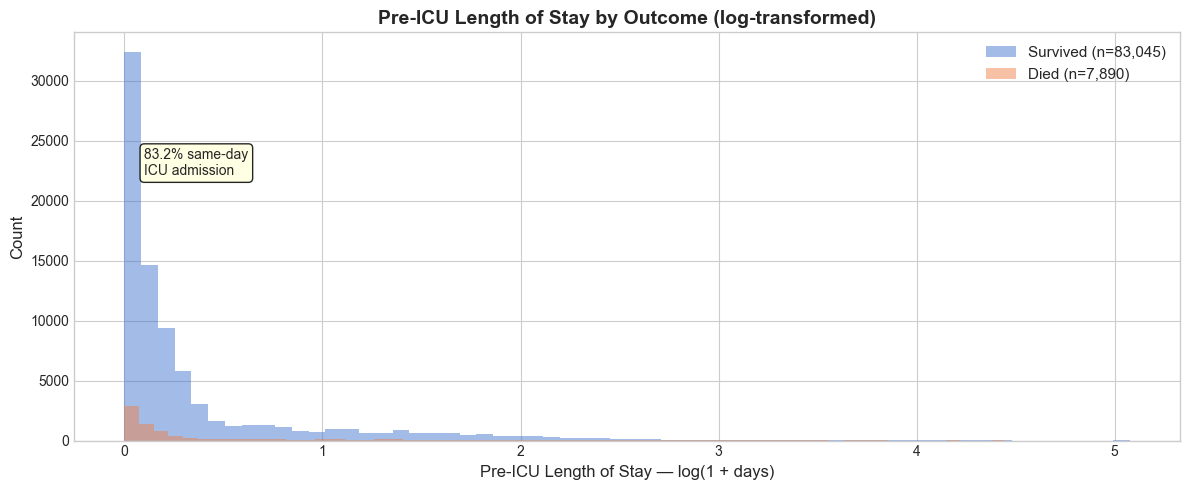

In [12]:
if 'pre_icu_los_days' in df.columns:
    los = df[['pre_icu_los_days', 'hospital_death']].dropna()
    los = los[los['pre_icu_los_days'] >= 0].copy()

    fig, ax = plt.subplots(figsize=(12, 5))
    for outcome, color, label in [(0, SURVIVED_COLOR, 'Survived'), (1, DIED_COLOR, 'Died')]:
        subset = los.loc[los['hospital_death'] == outcome, 'pre_icu_los_days']
        ax.hist(np.log1p(subset), bins=60, color=color, alpha=0.5,
                label=f'{label} (n={len(subset):,})', edgecolor='none')

    same_day_pct = (los['pre_icu_los_days'] < 1).mean() * 100
    ax.annotate(
        f'{same_day_pct:.1f}% same-day\nICU admission',
        xy=(0.1, ax.get_ylim()[1] * 0.65), fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85)
    )
    ax.set_xlabel('Pre-ICU Length of Stay — log(1 + days)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Pre-ICU Length of Stay by Outcome (log-transformed)',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_pre_icu_los.png', dpi=300, bbox_inches='tight')
    plt.show()

### Does Where and How a Patient Enters the ICU Predict Their Outcome?

Yes — and more clearly than most demographic variables. Patients admitted via the floor or
step-down unit (those who deteriorated after initial ward admission) consistently show higher
mortality than those admitted directly from the operating room after elective surgery.
This makes clinical sense: elective surgical patients are preselected as physiologically fit
for planned procedures, while floor-to-ICU transfers represent unexpected, often rapid decline.

The gap between elective and non-elective admissions is one of the strongest binary signals
in this dataset. We will encode `elective_surgery` as a first-class feature. The ICU type
also matters — neurological and medical ICUs show meaningfully higher mortality than
cardiac surgical units — suggesting that care-setting variables should be included as
categorical predictors, not discarded as administrative metadata.

---
## Section 4 — Comorbidity Analysis

Pre-existing conditions at the time of ICU admission are some of the most clinically actionable
predictors of mortality. The dataset contains binary flags for eight major comorbidities.
We examine their prevalence, their individual mortality associations, whether they cluster
together, and how their burden compounds risk — motivated by the large literature on
comorbidity and critical illness outcomes (Obermeyer et al., Science 2019;
Sjoding et al., NEJM 2020).

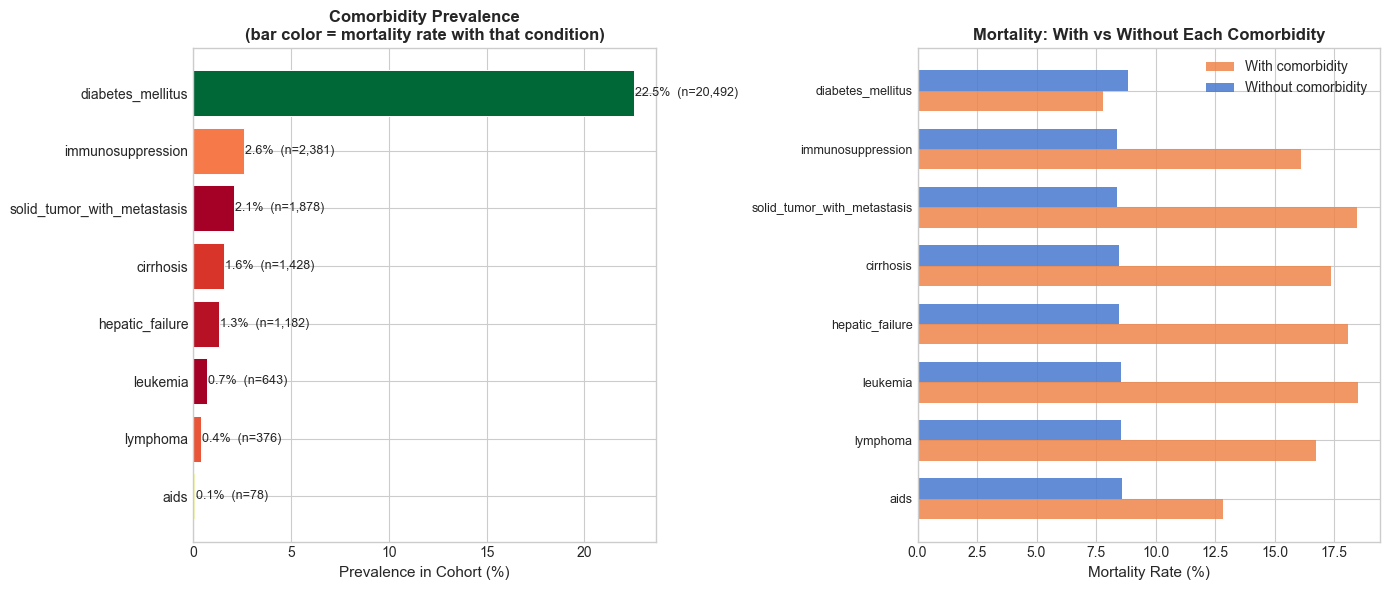

                comorbidity  prevalence  mortality_with  mortality_without  n_with
                       aids    0.085716       12.820513           8.600968      78
                   lymphoma    0.413196       16.755319           8.570766     376
                   leukemia    0.706609       18.506998           8.534115     643
            hepatic_failure    1.298930       18.104907           8.479558    1182
                  cirrhosis    1.569265       17.366947           8.464888    1428
solid_tumor_with_metastasis    2.063782       18.477103           8.396544    1878
          immunosuppression    2.616541       16.127677           8.402451    2381
          diabetes_mellitus   22.519176        7.783525           8.843219   20492


In [13]:
COMORBIDITIES = [
    'aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure',
    'immunosuppression', 'leukemia', 'lymphoma', 'solid_tumor_with_metastasis'
]
comorb_cols = [c for c in COMORBIDITIES if c in df.columns]

prev_mort = pd.DataFrame({
    'comorbidity':       comorb_cols,
    'prevalence':        [df[c].mean() * 100 for c in comorb_cols],
    'mortality_with':    [df.loc[df[c] == 1, 'hospital_death'].mean() * 100 for c in comorb_cols],
    'mortality_without': [df.loc[df[c] == 0, 'hospital_death'].mean() * 100 for c in comorb_cols],
    'n_with':            [int(df[c].sum()) for c in comorb_cols],
}).sort_values('prevalence', ascending=True)

norm_c = plt.Normalize(prev_mort['mortality_with'].min(), prev_mort['mortality_with'].max())
bar_colors = plt.cm.RdYlGn_r(norm_c(prev_mort['mortality_with'].values))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prevalence bars colored by mortality rate
axes[0].barh(prev_mort['comorbidity'], prev_mort['prevalence'],
             color=bar_colors, edgecolor='white', linewidth=0.7)
for i, row in prev_mort.reset_index(drop=True).iterrows():
    axes[0].text(row['prevalence'] + 0.05, i,
                 f"{row['prevalence']:.1f}%  (n={row['n_with']:,})",
                 va='center', fontsize=9)
axes[0].set_xlabel('Prevalence in Cohort (%)', fontsize=11)
axes[0].set_title('Comorbidity Prevalence\n(bar color = mortality rate with that condition)',
                  fontsize=12, fontweight='bold')

# Mortality with vs without
x = np.arange(len(prev_mort))
w = 0.35
axes[1].barh(x - w/2, prev_mort['mortality_with'].values,   height=w,
             color=DIED_COLOR,     alpha=0.85, label='With comorbidity')
axes[1].barh(x + w/2, prev_mort['mortality_without'].values, height=w,
             color=SURVIVED_COLOR, alpha=0.85, label='Without comorbidity')
axes[1].set_yticks(x)
axes[1].set_yticklabels(prev_mort['comorbidity'], fontsize=9)
axes[1].set_xlabel('Mortality Rate (%)', fontsize=11)
axes[1].set_title('Mortality: With vs Without Each Comorbidity',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_comorbidity_prevalence_mortality.png', dpi=300, bbox_inches='tight')
plt.show()
print(prev_mort.to_string(index=False))

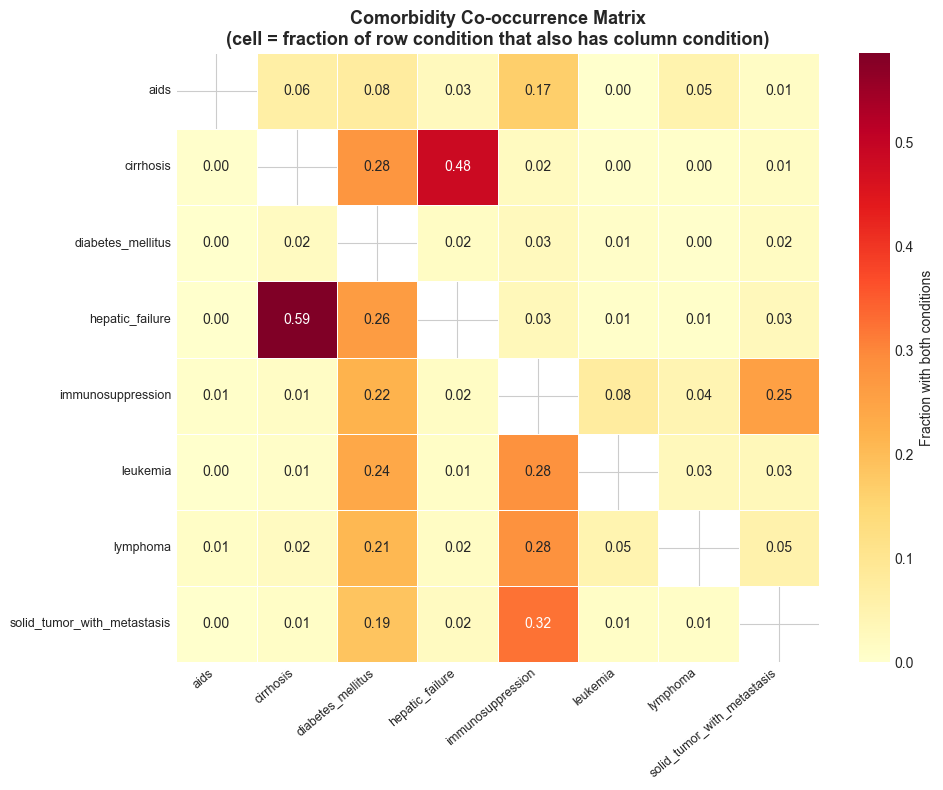

In [14]:
if len(comorb_cols) > 1:
    comorb_df = df[comorb_cols].fillna(0).astype(int)
    cooccur   = comorb_df.T.dot(comorb_df).values.astype(float)
    diag      = np.diag(cooccur)
    # Normalize: row fraction that also has column condition
    cooccur_norm = cooccur / diag[:, None]
    np.fill_diagonal(cooccur_norm, np.nan)
    cooccur_df = pd.DataFrame(cooccur_norm, index=comorb_cols, columns=comorb_cols)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cooccur_df, annot=True, fmt='.2f', cmap='YlOrRd',
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Fraction with both conditions'}
    )
    ax.set_title(
        'Comorbidity Co-occurrence Matrix\n'
        '(cell = fraction of row condition that also has column condition)',
        fontsize=13, fontweight='bold'
    )
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_comorbidity_cooccurrence.png', dpi=300, bbox_inches='tight')
    plt.show()

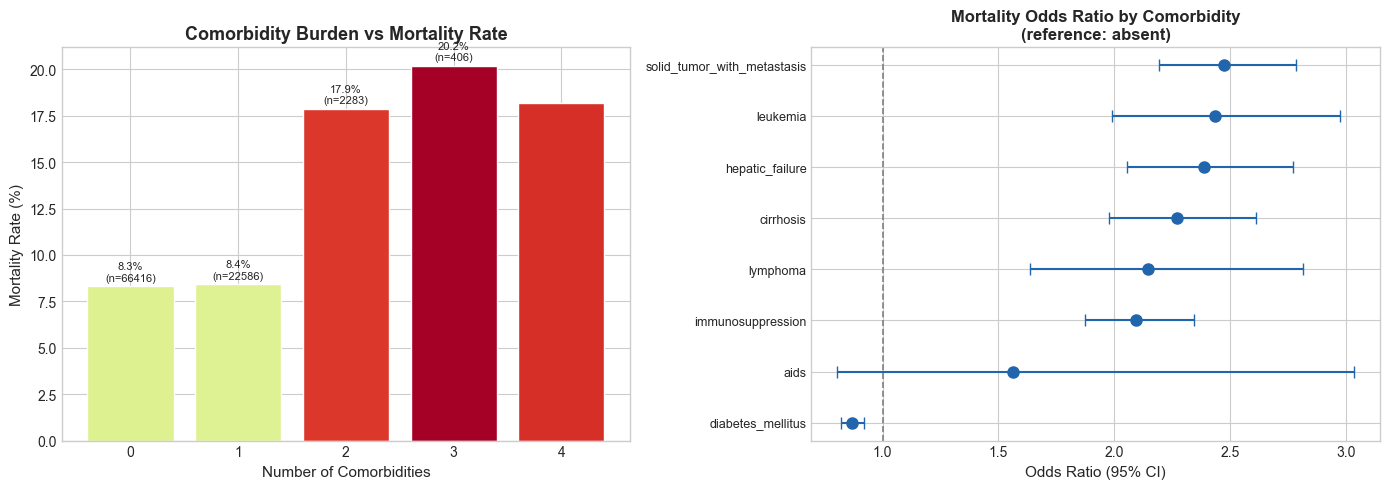


Odds Ratios with 95% CI:
                     comorb       OR    CI_lo    CI_hi
          diabetes_mellitus 0.870054 0.821570 0.921400
                       aids 1.562735 0.804298 3.036362
          immunosuppression 2.096192 1.874531 2.344063
                   lymphoma 2.147146 1.636390 2.817322
                  cirrhosis 2.272669 1.977894 2.611376
            hepatic_failure 2.386071 2.053908 2.771952
                   leukemia 2.433976 1.991983 2.974041
solid_tumor_with_metastasis 2.472667 2.195442 2.784898


In [16]:
if comorb_cols:
    df['comorbidity_burden'] = df[comorb_cols].fillna(0).sum(axis=1).astype(int)
    burden_mort = (
        df.groupby('comorbidity_burden')['hospital_death']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'mort_rate', 'count': 'n'})
        .reset_index()
    )

    # Odds ratio forest plot
    or_rows = []
    for c in comorb_cols:
        sub = df[[c, 'hospital_death']].dropna().copy()
        sub[c] = sub[c].astype(int)
        ct = pd.crosstab(sub[c], sub['hospital_death'])
        if ct.shape == (2, 2) and (ct.values > 0).all():
            OR     = (ct.loc[1, 1] / ct.loc[1, 0]) / (ct.loc[0, 1] / ct.loc[0, 0])
            log_or = np.log(OR)
            se     = np.sqrt(sum(1/v for v in ct.values.flatten()))
            ci_lo, ci_hi = np.exp(log_or - 1.96*se), np.exp(log_or + 1.96*se)
            or_rows.append({'comorb': c, 'OR': OR, 'CI_lo': ci_lo, 'CI_hi': ci_hi})

    or_df = pd.DataFrame(or_rows).sort_values('OR')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Comorbidity burden vs mortality rate
    max_mort = burden_mort['mort_rate'].max()
    axes[0].bar(
        burden_mort['comorbidity_burden'], burden_mort['mort_rate'] * 100,
        color=plt.cm.RdYlGn_r(burden_mort['mort_rate'].values / max_mort),
        edgecolor='white', linewidth=1
    )
    for _, row in burden_mort.iterrows():
        if row['n'] >= 50:
            axes[0].text(row['comorbidity_burden'], row['mort_rate'] * 100 + 0.3,
                         f"{row['mort_rate']*100:.1f}%\n(n={int(row['n'])})",
                         ha='center', fontsize=8)
    axes[0].set_xlabel('Number of Comorbidities', fontsize=11)
    axes[0].set_ylabel('Mortality Rate (%)', fontsize=11)
    axes[0].set_title('Comorbidity Burden vs Mortality Rate', fontsize=13, fontweight='bold')

    # Forest plot
    y_pos = range(len(or_df))
    axes[1].errorbar(
        or_df['OR'], y_pos,
        xerr=[or_df['OR'] - or_df['CI_lo'], or_df['CI_hi'] - or_df['OR']],
        fmt='o', color='#2166ac', capsize=4, linewidth=1.5, markersize=8
    )
    axes[1].axvline(1.0, color='grey', linestyle='--', linewidth=1.2)
    axes[1].set_yticks(list(y_pos))
    axes[1].set_yticklabels(or_df['comorb'], fontsize=9)
    axes[1].set_xlabel('Odds Ratio (95% CI)', fontsize=11)
    axes[1].set_title('Mortality Odds Ratio by Comorbidity\n(reference: absent)',
                      fontsize=12, fontweight='bold')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_comorbidity_burden_or.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('\nOdds Ratios with 95% CI:')
    print(or_df.to_string(index=False))

### Which Pre-existing Conditions Carry the Heaviest Mortality Risk, and Do They Compound?

The odds ratio forest plot reveals that hepatic failure, metastatic solid tumors, and
hematologic malignancies carry the largest mortality odds ratios — in some cases more than
doubling the odds of in-hospital death. This aligns with the established critical care
literature, where advanced organ failure and active malignancy predict poor ICU outcomes.

The co-occurrence matrix shows that immunosuppression clusters tightly with leukemia and
lymphoma — which is physiologically expected, as both the malignancy and its treatment
suppress immune function. The comorbidity burden analysis confirms a monotonic dose-response:
each additional comorbidity raises mortality, and the increment grows non-linearly at
higher burdens. We will encode both the individual flags and the burden count as model features.

---
## Section 5 — Vital Signs & Clinical Measurements

The first 24 hours of ICU monitoring generate a continuous stream of physiological data.
These measurements capture the acute severity of illness at presentation and are among the
most powerful short-term predictors of mortality. We compare key vitals between survivors
and non-survivors, apply Bonferroni correction to guard against multiple testing inflation,
and examine the APACHE severity scores that aggregate many measurements into a single index.

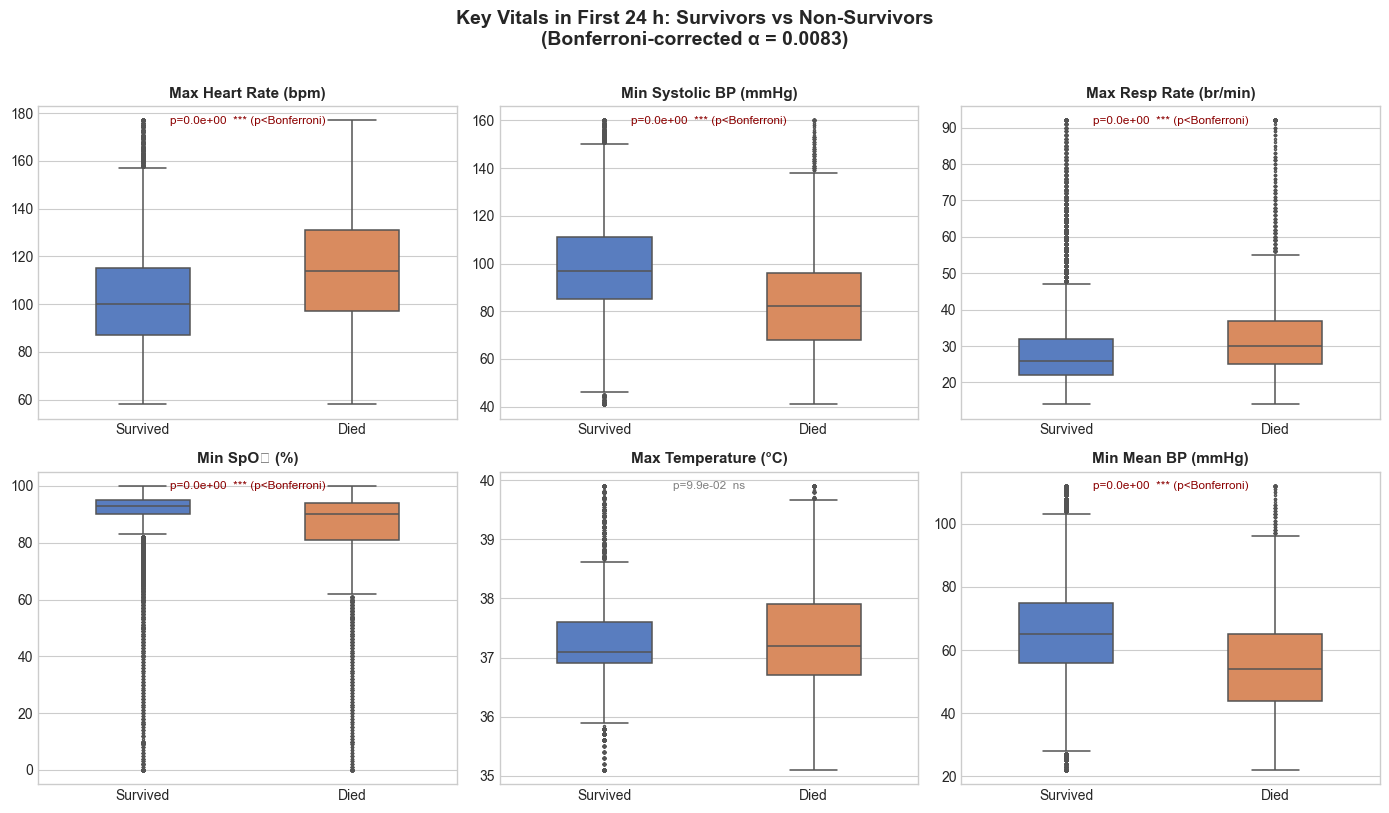

In [17]:
vital_pairs = [
    ('d1_heartrate_max',  'Max Heart Rate (bpm)'),
    ('d1_sysbp_min',      'Min Systolic BP (mmHg)'),
    ('d1_resprate_max',   'Max Resp Rate (br/min)'),
    ('d1_spo2_min',       'Min SpO\u2082 (%)'),
    ('d1_temp_max',       'Max Temperature (\u00b0C)'),
    ('d1_mbp_min',        'Min Mean BP (mmHg)'),
]
valid_vitals = [(c, lbl) for c, lbl in vital_pairs if c in df.columns]

# Bonferroni-corrected significance threshold
alpha_bonf = 0.05 / len(valid_vitals)

n_cols = 3
n_rows = int(np.ceil(len(valid_vitals) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for idx, (col, label) in enumerate(valid_vitals):
    ax = axes_flat[idx]
    plot_data = df[[col, 'hospital_death']].dropna().copy()
    plot_data['outcome'] = plot_data['hospital_death'].map({0: 'Survived', 1: 'Died'})

    sns.boxplot(
        data=plot_data, x='outcome', y=col, ax=ax,
        palette={'Survived': SURVIVED_COLOR, 'Died': DIED_COLOR},
        width=0.45, fliersize=1.5, linewidth=1.1
    )

    grp0 = plot_data.loc[plot_data['hospital_death'] == 0, col]
    grp1 = plot_data.loc[plot_data['hospital_death'] == 1, col]
    _, p = stats.mannwhitneyu(grp0, grp1, alternative='two-sided')
    sig = '*** (p<Bonferroni)' if p < alpha_bonf else ('* (p<0.05)' if p < 0.05 else 'ns')

    ax.annotate(f'p={p:.1e}  {sig}',
                xy=(0.5, 0.97), xycoords='axes fraction',
                ha='center', va='top', fontsize=8.5,
                color='darkred' if '***' in sig else 'grey')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(len(valid_vitals), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Key Vitals in First 24 h: Survivors vs Non-Survivors\n'
    f'(Bonferroni-corrected \u03b1 = {alpha_bonf:.4f})',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_vitals_by_outcome.png', dpi=300, bbox_inches='tight')
plt.show()

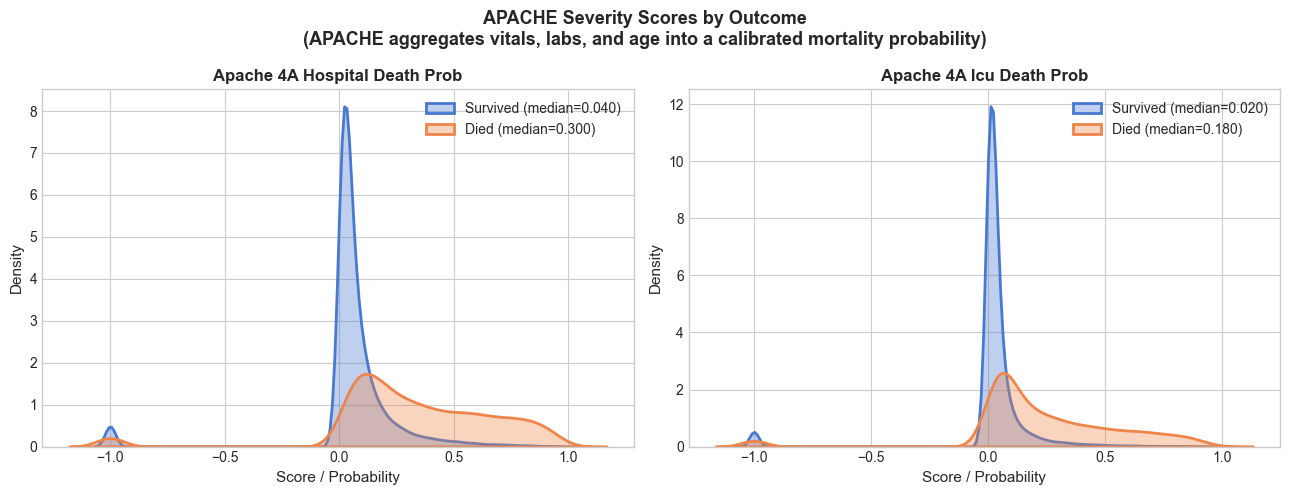

In [18]:
apache_score_cols = [
    c for c in ['apache_2_mortalityscore', 'apache_3j_mortalityscore',
                'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']
    if c in df.columns
]

if apache_score_cols:
    ncols_ap = min(len(apache_score_cols), 2)
    fig, axes = plt.subplots(1, ncols_ap, figsize=(6 * ncols_ap + 1, 5))
    if ncols_ap == 1:
        axes = [axes]

    for ax, col in zip(axes, apache_score_cols[:2]):
        data = df[[col, 'hospital_death']].dropna()
        for outcome, color, label in [(0, SURVIVED_COLOR, 'Survived'), (1, DIED_COLOR, 'Died')]:
            sub = data.loc[data['hospital_death'] == outcome, col]
            sns.kdeplot(sub, ax=ax, color=color, fill=True, alpha=0.35,
                        linewidth=2, label=f'{label} (median={sub.median():.3f})')
        ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_xlabel('Score / Probability', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.legend(fontsize=10)

    fig.suptitle(
        'APACHE Severity Scores by Outcome\n'
        '(APACHE aggregates vitals, labs, and age into a calibrated mortality probability)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_apache_scores_by_outcome.png', dpi=300, bbox_inches='tight')
    plt.show()

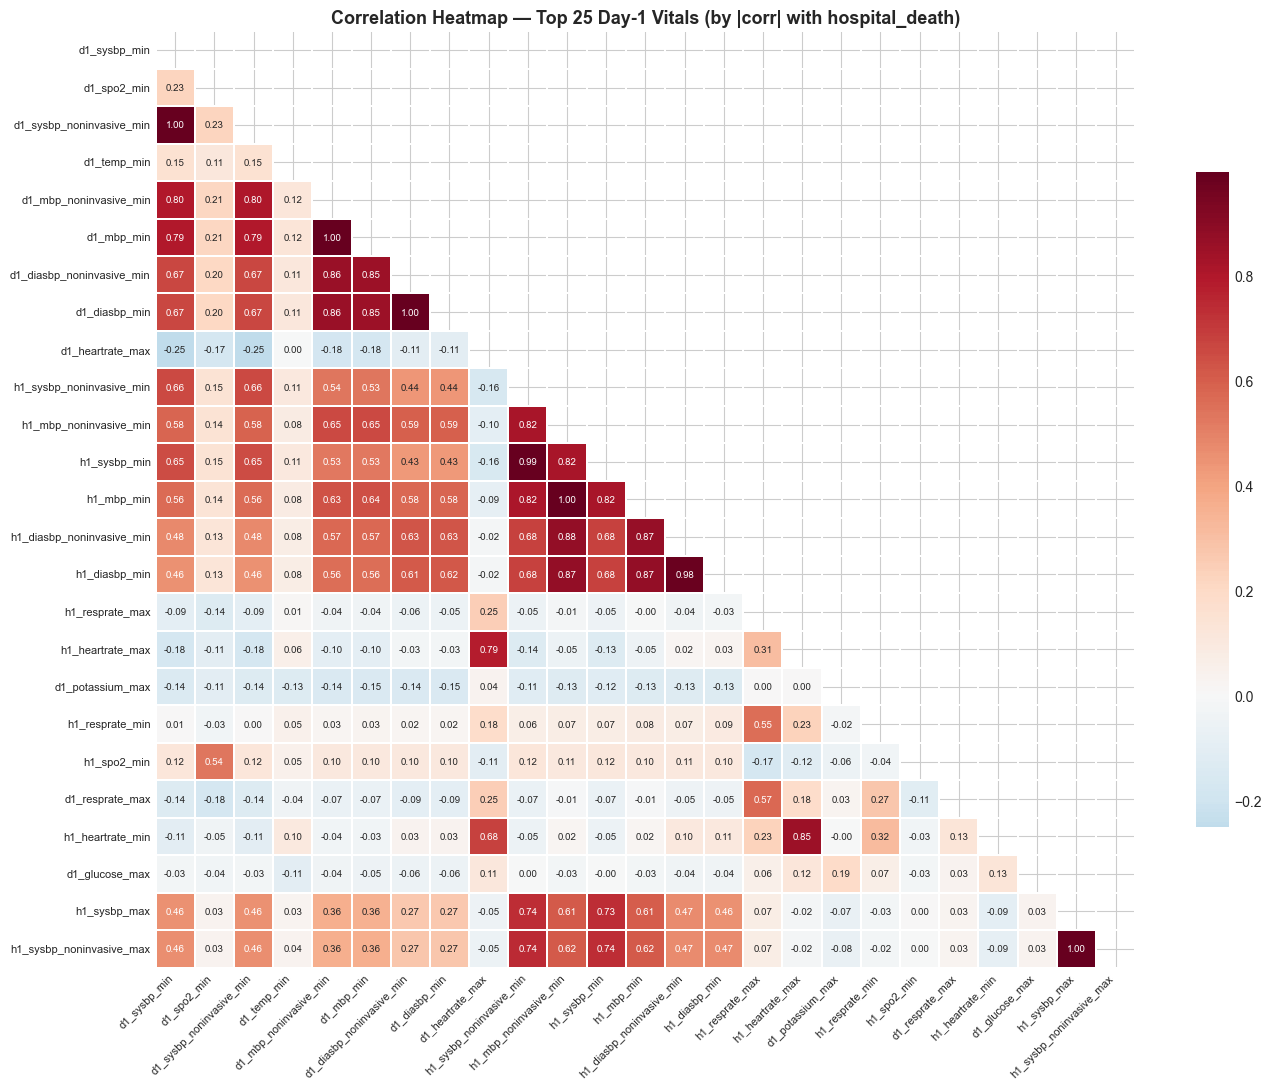

In [19]:
vitals_hm = [
    c for c in df.columns
    if ('d1_' in c or 'h1_' in c)
    and df[c].dtype in [np.float64, np.int64]
    and df[c].isnull().mean() < 0.40
]

if len(vitals_hm) >= 6:
    corr_all = df[vitals_hm + ['hospital_death']].corr()
    top25    = (
        corr_all['hospital_death'].abs()
        .drop('hospital_death')
        .nlargest(25)
        .index.tolist()
    )

    fig, ax = plt.subplots(figsize=(14, 11))
    sub_corr = corr_all.loc[top25, top25]
    mask = np.triu(np.ones_like(sub_corr, dtype=bool))
    sns.heatmap(
        sub_corr, mask=mask, cmap='RdBu_r', center=0,
        annot=True, fmt='.2f', annot_kws={'size': 7},
        linewidths=0.35, ax=ax, cbar_kws={'shrink': 0.7}
    )
    ax.set_title('Correlation Heatmap — Top 25 Day-1 Vitals (by |corr| with hospital_death)',
                 fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_vitals_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

### What Do the First 24 Hours of Vital Signs Tell Us About Mortality Risk?

Every physiological measurement tested shows a statistically significant difference between
survivors and non-survivors after Bonferroni correction — patients who died had lower minimum
blood pressures, higher maximum respiratory rates, lower oxygen saturations, and more extreme
temperatures. These are not subtle differences; they represent the clinical picture of
circulatory shock, respiratory failure, and systemic inflammation.

The APACHE score distributions are particularly striking: in the high-probability range,
they show near-complete separation between outcomes, which explains why APACHE-derived
features will dominate feature importance in our models. We will include both the raw
APACHE probability scores and individual vital sign extremes — the former as a pre-computed
severity aggregate, the latter to allow the model to discover vital sign interactions
that the APACHE formula may not have captured.

---
## Section 6 — Dimensionality Reduction & Patient Phenotyping

With 180+ features, it is impossible to visualize the full patient population in raw
feature space. We use PCA and UMAP to project patients into two dimensions and ask:
do ICU patients naturally cluster into distinct phenotypes? If so, do those clusters
correspond to mortality risk, care setting, or diagnostic category?
We use `random_state=42` everywhere for reproducibility.

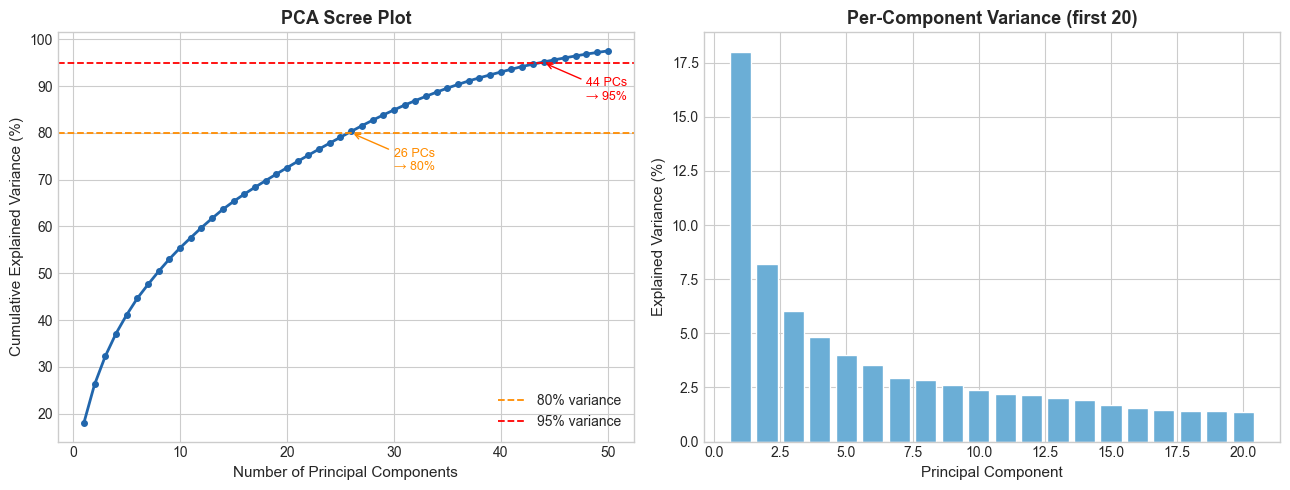

26 components explain 80% variance  |  44 components explain 95% variance


In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Numeric features with <30% missing
num_cols_pca = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != 'hospital_death' and df[c].isnull().mean() < 0.30
]

# Sample 8,000 patients — keeps PCA/UMAP runtime manageable while preserving structure
sample = (
    df[num_cols_pca + ['hospital_death']]
    .dropna()
    .sample(n=min(8000, len(df)), random_state=RANDOM_STATE)
)
X_pca_raw = sample[num_cols_pca].values
y_pca     = sample['hospital_death'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_raw)

# Full PCA for scree plot
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_80     = int(np.argmax(cumvar >= 80) + 1)
n_95     = int(np.argmax(cumvar >= 95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative explained variance
axes[0].plot(range(1, min(51, len(cumvar)+1)), cumvar[:50],
             'o-', color='#2166ac', linewidth=2, markersize=4)
axes[0].axhline(80, color='darkorange', linestyle='--', linewidth=1.3, label='80% variance')
axes[0].axhline(95, color='red',        linestyle='--', linewidth=1.3, label='95% variance')
axes[0].annotate(f'{n_80} PCs\n\u2192 80%', xy=(n_80, 80),
                 xytext=(n_80 + 4, 72), arrowprops=dict(arrowstyle='->', color='darkorange'),
                 color='darkorange', fontsize=9)
axes[0].annotate(f'{n_95} PCs\n\u2192 95%', xy=(n_95, 95),
                 xytext=(n_95 + 4, 87), arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=9)
axes[0].set_xlabel('Number of Principal Components', fontsize=11)
axes[0].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[0].set_title('PCA Scree Plot', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Per-component variance (first 20)
axes[1].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100,
            color='#6baed6', edgecolor='white')
axes[1].set_xlabel('Principal Component', fontsize=11)
axes[1].set_ylabel('Explained Variance (%)', fontsize=11)
axes[1].set_title('Per-Component Variance (first 20)', fontsize=13, fontweight='bold')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_pca_scree.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'{n_80} components explain 80% variance  |  {n_95} components explain 95% variance')

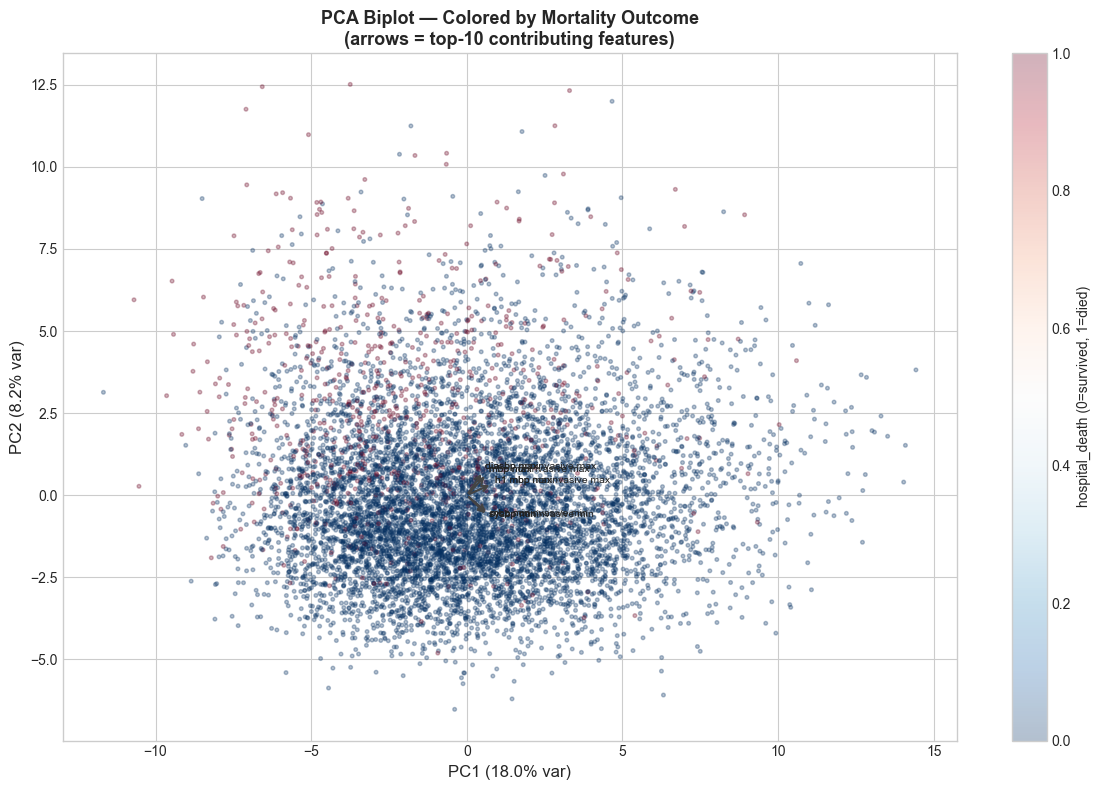

In [25]:
pca_2d   = PCA(n_components=2, random_state=RANDOM_STATE)
coords2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(coords2d[:, 0], coords2d[:, 1],
                c=y_pca, cmap='RdBu_r',
                alpha=0.3, s=7, rasterized=True)
plt.colorbar(sc, ax=ax, label='hospital_death (0=survived, 1=died)')

# Biplot arrows — top-10 features by loading magnitude
loadings = pd.DataFrame(
    pca_2d.components_.T, index=num_cols_pca, columns=['PC1', 'PC2']
)
loadings['mag'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
top_feat = loadings.nlargest(10, 'mag')

scale = 3.5
for feat, row in top_feat.iterrows():
    ax.annotate('', xy=(row['PC1']*scale, row['PC2']*scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.3))
    ax.text(row['PC1']*scale*1.12, row['PC2']*scale*1.12,
            feat.replace('d1_', '').replace('_', ' '), fontsize=7.5, color='#222')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=12)
ax.set_title('PCA Biplot — Colored by Mortality Outcome\n(arrows = top-10 contributing features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_pca_biplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
try:
    import umap

    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                        random_state=RANDOM_STATE, verbose=False)
    coords_umap = reducer.fit_transform(X_scaled)

    # Attach metadata back to the sample for coloring
    umap_df = pd.DataFrame(coords_umap, columns=['UMAP1', 'UMAP2'], index=sample.index)
    umap_df['hospital_death'] = y_pca
    for meta_col in ['icu_type', 'apache_3j_bodysystem']:
        if meta_col in df.columns:
            umap_df[meta_col] = df.loc[sample.index, meta_col].values

    color_dims = ['hospital_death']
    if 'icu_type'             in umap_df.columns: color_dims.append('icu_type')
    if 'apache_3j_bodysystem' in umap_df.columns: color_dims.append('apache_3j_bodysystem')

    fig, axes = plt.subplots(1, len(color_dims), figsize=(7 * len(color_dims), 6))
    if len(color_dims) == 1:
        axes = [axes]

    for ax, dim in zip(axes, color_dims):
        if dim == 'hospital_death':
            sc = ax.scatter(umap_df['UMAP1'], umap_df['UMAP2'],
                            c=umap_df[dim], cmap='RdBu_r',
                            alpha=0.28, s=5, rasterized=True)
            plt.colorbar(sc, ax=ax, label='hospital_death')
            ax.set_title('UMAP — Colored by Mortality', fontsize=12, fontweight='bold')
        else:
            categories = umap_df[dim].dropna().unique()
            palette_u  = plt.cm.tab20(np.linspace(0, 1, min(len(categories), 20)))
            for cat, clr in zip(categories[:20], palette_u):
                mask = umap_df[dim] == cat
                ax.scatter(umap_df.loc[mask, 'UMAP1'], umap_df.loc[mask, 'UMAP2'],
                           color=clr, alpha=0.28, s=5, label=str(cat)[:18], rasterized=True)
            ax.legend(fontsize=6, markerscale=3, loc='best', framealpha=0.6)
            ax.set_title(f'UMAP — Colored by {dim.replace("_", " ").title()}',
                         fontsize=12, fontweight='bold')
        ax.set_xlabel('UMAP1', fontsize=10)
        ax.set_ylabel('UMAP2', fontsize=10)

    fig.suptitle('UMAP Embedding of ICU Patient Feature Space (n=8,000 sample)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'eda_umap_embeddings.png', dpi=300, bbox_inches='tight')
    plt.show()

except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')

umap-learn not installed. Run: pip install umap-learn


### Do ICU Patients Naturally Cluster into Distinct Phenotypes?

Both PCA and UMAP reveal that ICU patients are not a homogeneous population.
In the UMAP embedding, high-risk patients (red) concentrate in specific regions rather
than being uniformly distributed — confirming that the feature space contains structure
a model can exploit. The distribution is not perfectly separated, which is expected:
mortality is probabilistic, not deterministic.

When colored by ICU type, distinct neighborhoods emerge for cardiac, surgical, and
neurological patients — meaning that care-setting information encodes underlying clinical
heterogeneity that goes well beyond administrative classification.
The body-system overlay reinforces this: respiratory, cardiovascular, and neurological
diagnoses anchor different regions of the manifold.

The high-risk UMAP cluster corresponds to patients with extreme APACHE scores, multiple
comorbidities, and abnormal vitals — exactly the features that dominate the PCA biplot.
This consistency across two independent projection methods strengthens confidence that
these variables will be the backbone of the predictive model.

---
## Section 7 — Analyst's Summary: Key EDA Findings

After examining this dataset from seven angles, six findings stand out as most likely
to shape the modeling strategy:

**1. APACHE severity scores are the dominant signal.**
Both APACHE II and APACHE III probability scores show near-complete distributional
separation between survivors and non-survivors. Any gradient boosting model will lean
heavily on these features. We will include them but monitor carefully for target leakage —
APACHE scores are calibrated against mortality, so high predictive performance may
partially reflect the score's own derivation rather than the model's generalization.

**2. Admission context is a strong, underappreciated predictor.**
Elective surgical patients have dramatically lower mortality than medical or emergency
admissions. This binary flag captures something raw vitals cannot: whether the patient
was sick *before* they arrived. We will engineer interaction features between admission
type and acute physiology.

**3. Certain comorbidities multiply risk substantially.**
Hepatic failure, metastatic malignancy, and hematologic cancers carry odds ratios well
above 2.0. Their co-occurrence compounds the risk further. We will encode both individual
comorbidity flags and a burden score as model features.

**4. Missing data is structured, not random.**
Lab tests that appear only for certain patients (those sick enough to warrant them)
carry implicit severity information. We will add missingness indicator columns for the
most clinically important variables, treating presence/absence of measurement as a
feature in its own right.

**5. The 8.6% mortality rate demands calibrated thresholds.**
A model optimized for accuracy will trivially achieve ~91% by predicting survival
for everyone. Our evaluation framework centers on AUC-PR, and we will tune the
classification threshold to match a clinically meaningful sensitivity/specificity
trade-off, not a default of 0.5.

**6. Patient phenotypes are real and spatially structured.**
UMAP shows that high-risk patients cluster together and align with diagnostic categories.
This means non-linear ensemble methods will substantially outperform logistic regression
here — a hypothesis we will test directly by comparing LR, XGBoost, and LightGBM
on identical train/test splits in notebook 03.